In [1]:
##########################################
# Añadir esto al principio de cada ipynb #
##########################################
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/MyDrive/_UOC/tfm-solar-forecasting/')

# Verifica que existan las carpetas esperadas
!ls
# Debes ver 'src' y 'config'

Mounted at /content/drive
checkpoints  data  lightning_logs  README.md	     results
config	     doc   notebooks	   requirements.txt  src


# EDA y Preprocesado de Datos — 6 Plantas Solares

**Objetivo:** Cargar, validar, explorar y preparar los splits train/val/test
para los experimentos de forecasting solar (Exp 1, 2 y 3).

**Dataset:** 6 plantas fotovoltaicas, Sep 2024 – Dic 2025
| Planta | MW | Tipo | Zona | Rol | Datos |
|--------|-----|------|------|-----|-------|
| UPGARNACHA | 149 | tracker | Norte | fuente | 2025 only |
| FVARENA | 150 | tracker | Centro | fuente | Sep 2024 – Dic 2025 |
| NBALBOA | 499 | fijo | Centro | fuente | Sep 2024 – Dic 2025 |
| RODRI | 175 | tracker | Sur | fuente | Sep 2024 – Dic 2025 |
| UFMULA | 494 | fijo | Sur | fuente | Sep 2024 – Dic 2025 |
| TALASOL | 300 | fijo | Centro | **target** | Sep 2024 – Dic 2025 |

> **Nota:** FVARENA sustituye a PIZARRO (590 MW) que presentaba un 18% de ceros
> anómalos, incluyendo ~540h de paradas planificadas en pleno periodo de entrenamiento
> (junio–octubre). FVARENA tiene <2% de anomalías reales tras corrección.
>
> **UPGARNACHA** solo dispone de datos de 2025 (limitación documentada).

---
### Google Colab — ejecutar PRIMERO
```python
from google.colab import drive; drive.mount('/content/drive')
import os; os.chdir('/content/drive/MyDrive/_MCD/TFM/MUDS-TFM/tfm-solar-forecasting/')
```


In [2]:
##########################################
# Añadir esto al principio de cada ipynb #
##########################################
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/MyDrive/_UOC/tfm-solar-forecasting/')

# Verifica que existan las carpetas esperadas
!ls
# Debes ver 'src' y 'config'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
checkpoints  data  lightning_logs  README.md	     results
config	     doc   notebooks	   requirements.txt  src


In [3]:
# ============================================================================
# CELDA 0 — Instalación de dependencias (solo necesario en Colab)
# ============================================================================
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print('Instalando dependencias para Colab...')
    import subprocess
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install',
         'pvlib', 'prophet', 'plotly',
         '--quiet', '--no-warn-script-location'],
        check=False
    )
    print('Instalación completada.')
else:
    print('Entorno local — dependencias ya instaladas.')

Instalando dependencias para Colab...
Instalación completada.


In [4]:
# ============================================================================
# CELDA 1 — Setup: path, imports
# ============================================================================
import sys
import pathlib as _pl

# Detectar raíz del repositorio desde el directorio actual.
# En Colab: monta Drive y ejecuta os.chdir() al repo ANTES de esta celda.
#   from google.colab import drive; drive.mount('/content/drive')
#   import os; os.chdir('/content/drive/MyDrive/_MCD/TFM/MUDS-TFM/tfm-solar-forecasting/')
_root = next(
    (p for p in [_pl.Path.cwd(), *_pl.Path.cwd().parents]
     if (p / 'src').is_dir() and (p / 'config' / 'settings.py').exists()),
    None
)
if _root is None:
    raise RuntimeError(
        f'No se encontró la raíz del repo. cwd={_pl.Path.cwd()}\n'
        'En Colab: monta Drive y ejecuta os.chdir() al repo antes de esta celda.'
    )
sys.path.insert(0, str(_root / 'src'))
del _pl, _root

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

from data_processing import SolarDataProcessor

# Módulo ex1
from ex1_compare import DATA_DIR, RESULTS_DIR
from ex1_compare.ex1_config import PLANTAS

# Estilo visual
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

# Paleta de colores por planta
PALETTE = {
    'UPGARNACHA': '#4E79A7',
    'FVARENA':    '#F28E2B',  # sustituye a PIZARRO
    'NBALBOA':    '#E15759',
    'RODRI':      '#76B7B2',
    'UFMULA':     '#59A14F',
    'TALASOL':    '#B07AA1',
}

print('Setup completado.')
print(f'Plantas del experimento: {PLANTAS}')

[ex1] Entorno: Google Colab | Device: cpu (CUDA no disponible)
Setup completado.
Plantas del experimento: ['UPGARNACHA', 'FVARENA', 'NBALBOA', 'RODRI', 'UFMULA', 'TALASOL']


In [5]:
# ============================================================================
# CELDA 2 — Carga y procesado de datos (pipeline completo)
# ============================================================================
import shutil

# FVARENA está en data/no/ (excluida del dataset original).
# La copiamos a data/ para que el pipeline la descubra automáticamente.
# Cuando estén disponibles los datos de 2024, reemplazar por el CSV consolidado.
_fvarena_src = Path('data/no/FVARENA-merged-2025.csv')
_fvarena_dst = Path('data/FVARENA-merged-2025.csv')
if not _fvarena_dst.exists():
    if _fvarena_src.exists():
        shutil.copy(_fvarena_src, _fvarena_dst)
        print(f'FVARENA copiada de data/no/ a data/')
    else:
        raise FileNotFoundError(
            'No se encontró FVARENA-merged-2025.csv en data/no/. '
            'Coloca el archivo en data/no/ antes de ejecutar.'
        )
else:
    print('FVARENA ya presente en data/')

# Pipeline completo:
#   1. Carga CSVs de todas las plantas en data/ (patrón *-merged-2025.csv)
#   2. Validación de datos crudos
#   3. Merge con metadatos de plantas
#   4. Posición solar (pvlib)
#   5. Features temporales
#   6. Limpieza de outliers
processor = SolarDataProcessor(data_dir='data')
df_raw = processor.process_pipeline()

# Filtrar a las 6 plantas del experimento (excluye PIZARRO y otras aún en data/)
df = df_raw[df_raw['planta_nombre'].isin(PLANTAS)].copy()

print(f'\nDataset cargado: {len(df):,} registros × {len(df.columns)} columnas')
print(f'Plantas: {sorted(df["planta_nombre"].unique())}')

FVARENA ya presente en data/

PIPELINE DE PROCESAMIENTO DE DATOS
Dataset: 6 plantas solares, Sep 2024 – Dic 2025

[1/7] Cargando datos...
✓ Leído datos_plantas.csv usando codificación: utf-8
✓ Cargada info de 14 plantas
  Distribución por zona climática:
zona_climatica
Centro    10
Sur        3
Norte      1

Encontrados 11 archivos de plantas:
  - FVARENA (FVARENA-merged-2024.csv): 2,928 registros (2024-09-01 a 2024-12-31)
  - FVARENA (FVARENA-merged-2025.csv): 8,668 registros (2025-01-01 a 2025-12-31)
  - NBALBOA (NBALBOA-merged-2024.csv): 2,928 registros (2024-09-01 a 2024-12-31)
  - NBALBOA (NBALBOA-merged-2025.csv): 8,645 registros (2025-01-01 a 2025-12-31)
  - RODRI (RODRI-merged-2024.csv): 2,928 registros (2024-09-01 a 2024-12-31)
  - RODRI (RODRI-merged-2025.csv): 8,668 registros (2025-01-01 a 2025-12-31)
  - TALASOL (TALASOL-merged-2024.csv): 2,928 registros (2024-09-01 a 2024-12-31)
  - TALASOL (TALASOL-merged-2025.csv): 8,668 registros (2025-01-01 a 2025-12-31)
  - UFMULA (UF

In [6]:
# ============================================================================
# CELDA 3 — Información básica del dataset
# ============================================================================
print('=' * 70)
print('RESUMEN DEL DATASET')
print('=' * 70)

# Info por planta
resumen = []
for planta in PLANTAS:
    df_p = df[df['planta_nombre'] == planta]
    if len(df_p) == 0:
        print(f'  ⚠  {planta}: no encontrada en el dataset')
        continue
    row = df_p.iloc[0]
    resumen.append({
        'Planta':    planta,
        'MW':        row['instalada_mw'],
        'Tipo':      'tracker' if row['seguimiento'] == 1 else 'fijo',
        'Zona':      row['zona_climatica'],
        'Registros': len(df_p),
        'Inicio':    pd.to_datetime(df_p['timestamp_utc']).min().date(),
        'Fin':       pd.to_datetime(df_p['timestamp_utc']).max().date(),
        'Prod_media_MW': round(float(df_p['produccion'].mean()), 2),
        'Prod_max_MW':   round(float(df_p['produccion'].max()), 2),
        'CF_%':  round(float(df_p['produccion'].mean() / row['instalada_mw'] * 100), 1),
    })

df_resumen = pd.DataFrame(resumen)
print(df_resumen.to_string(index=False))

# Columnas disponibles
print(f'\nColumnas ({len(df.columns)}): {list(df.columns)}')

RESUMEN DEL DATASET
    Planta      MW    Tipo   Zona  Registros     Inicio        Fin  Prod_media_MW  Prod_max_MW   CF_%
UPGARNACHA 149.000 tracker  Norte       8667 2025-01-01 2025-12-31         83.860      461.200 56.300
   FVARENA 150.310 tracker Centro      11595 2024-09-01 2025-12-31         34.600      386.400 23.000
   NBALBOA 499.080    fijo Centro      11572 2024-09-01 2025-12-31        144.580     1494.000 29.000
     RODRI 175.000 tracker    Sur      11595 2024-09-01 2025-12-31         67.620      525.600 38.600
    UFMULA 493.740    fijo    Sur      11595 2024-09-01 2025-12-31        189.880     1552.000 38.500
   TALASOL 300.610    fijo Centro      11595 2024-09-01 2025-12-31        118.750      901.600 39.500

Columnas (39): ['timestamp_utc', 'hour_number', 'produccion', 'temperature_2m', 'direct_normal_irradiance', 'shortwave_radiation', 'global_tilted_irradiance', 'wind_speed_10m', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high', 'relative_humid

=== Ceros anómalos: producción=0 con GTI ≥ 200 W/m² ===

    Planta  Horas activas  Ceros anómalos  % horas activas  GTI medio (W/m²)  GTI máx (W/m²)
UPGARNACHA           2831               9            0.320           668.000         937.000
   FVARENA           3742              41            1.100           592.700         950.000
   NBALBOA           3832             256            6.680           564.600         981.000
     RODRI           3920              67            1.710           442.200         947.000
    UFMULA           3938              19            0.480           491.400         930.000
   TALASOL           3676             191            5.200           590.900         963.000

Total anomalías detectadas: 583 horas

--- Detalle completo de ceros anómalos ---
    planta     Fecha-Hora  hora  GTI (W/m²)  SW (W/m²)  DNI (W/m²)  Nubes (%)
UPGARNACHA 2025-03-21 14h    14     235.000    235.000       4.100        100
UPGARNACHA 2025-04-28 11h    11     838.000    838.00

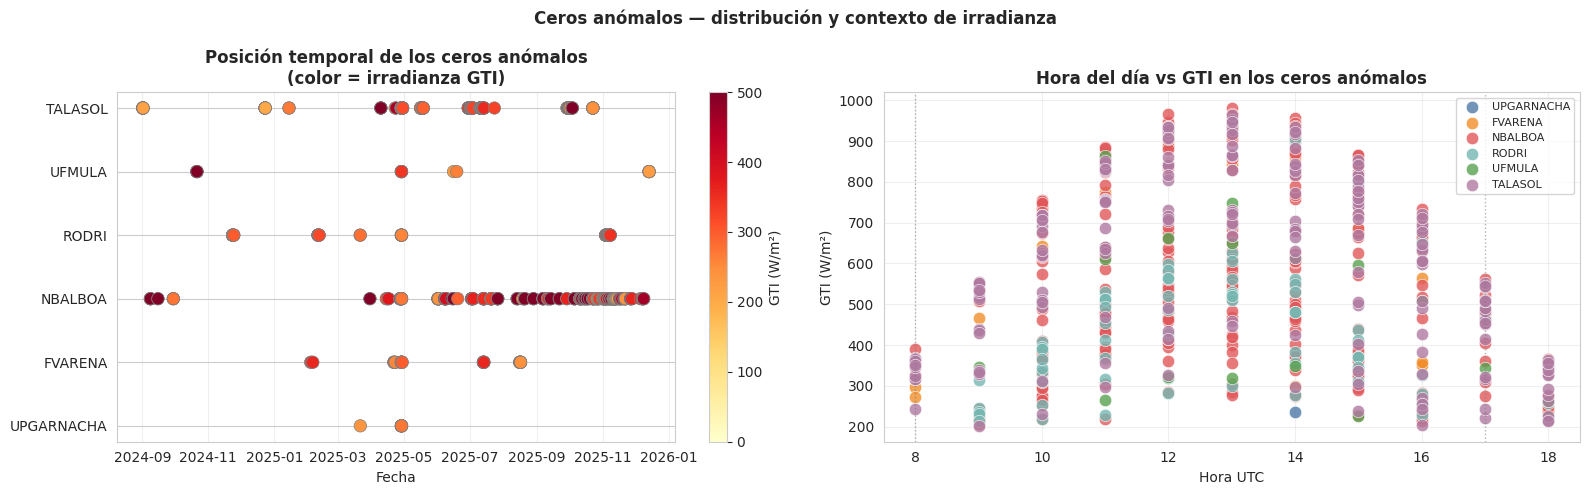


--- Contexto: producción en hora anterior y siguiente ---
    Planta     Fecha-Hora  Prod t-1  Prod t=0  Prod t+1  GTI (W/m²)
UPGARNACHA 2025-03-21 14h    54.000     0.000     0.000     235.000
UPGARNACHA 2025-04-28 11h    63.600     0.000     0.000     838.000
UPGARNACHA 2025-04-28 12h     0.000     0.000     0.000     917.000
UPGARNACHA 2025-04-28 13h     0.000     0.000     0.000     937.000
UPGARNACHA 2025-04-28 14h     0.000     0.000     0.000     898.000
UPGARNACHA 2025-04-28 15h     0.000     0.000     0.000     800.000
UPGARNACHA 2025-04-28 16h     0.000     0.000     0.000     650.000
UPGARNACHA 2025-04-28 17h     0.000     0.000     0.000     467.000
UPGARNACHA 2025-04-28 18h     0.000     0.000     0.000     270.000
   FVARENA 2025-02-03 16h    24.000     0.000     0.000     352.000
   FVARENA 2025-02-04 16h    17.200     0.000     0.000     350.000
   FVARENA 2025-02-05 16h    38.800     0.000     0.000     359.000
   FVARENA 2025-04-21 14h    27.600     0.000     0.000  

In [7]:
# ============================================================================
# CELDA 3b — Detección de ceros anómalos en producción
# ============================================================================
# Un cero exacto en producción durante horas con irradianza significativa
# indica un dato faltante registrado como 0 en ENTSO-e, no producción real nula.
# Umbral: GTI >= 200 W/m² → hora con radiación solar suficiente para producir.

IRR_THRESHOLD = 200  # W/m² en global_tilted_irradiance

fig_dir = RESULTS_DIR / 'figures' / 'eda'
fig_dir.mkdir(parents=True, exist_ok=True)

# ── 1. Detección ─────────────────────────────────────────────────────────────
anom_list = []
for planta in PLANTAS:
    df_p = df[df['planta_nombre'] == planta].copy()
    mask = (df_p['produccion'] == 0) & (df_p['global_tilted_irradiance'] >= IRR_THRESHOLD)
    df_anom = df_p[mask][[
        'timestamp_utc', 'produccion',
        'global_tilted_irradiance', 'shortwave_radiation',
        'direct_normal_irradiance', 'cloud_cover',
    ]].copy()
    df_anom.insert(0, 'planta', planta)
    anom_list.append(df_anom)

df_anom_all = pd.concat(anom_list, ignore_index=True)
df_anom_all['timestamp_utc'] = pd.to_datetime(df_anom_all['timestamp_utc'])
df_anom_all['hora'] = df_anom_all['timestamp_utc'].dt.hour

# ── 2. Resumen por planta ─────────────────────────────────────────────────────
print('=== Ceros anómalos: producción=0 con GTI ≥ 200 W/m² ===\n')
resumen_anom = []
for planta in PLANTAS:
    df_p   = df[df['planta_nombre'] == planta]
    n_actv = (df_p['global_tilted_irradiance'] >= IRR_THRESHOLD).sum()
    n_anom = (df_anom_all['planta'] == planta).sum()
    sub    = df_anom_all[df_anom_all['planta'] == planta]
    resumen_anom.append({
        'Planta':           planta,
        'Horas activas':    n_actv,
        'Ceros anómalos':   n_anom,
        '% horas activas':  round(n_anom / n_actv * 100, 2) if n_actv else 0,
        'GTI medio (W/m²)': round(sub['global_tilted_irradiance'].mean(), 1) if n_anom else 0,
        'GTI máx (W/m²)':   round(sub['global_tilted_irradiance'].max(), 1) if n_anom else 0,
    })

df_res_anom = pd.DataFrame(resumen_anom)
print(df_res_anom.to_string(index=False))
print(f'\nTotal anomalías detectadas: {len(df_anom_all)} horas')

# ── 3. Detalle de cada anomalía ───────────────────────────────────────────────
if len(df_anom_all) > 0:
    print('\n--- Detalle completo de ceros anómalos ---')
    df_show = df_anom_all.copy()
    df_show['timestamp_utc'] = df_show['timestamp_utc'].dt.strftime('%Y-%m-%d %Hh')
    print(df_show[[
        'planta', 'timestamp_utc', 'hora',
        'global_tilted_irradiance', 'shortwave_radiation',
        'direct_normal_irradiance', 'cloud_cover',
    ]].rename(columns={
        'timestamp_utc':            'Fecha-Hora',
        'global_tilted_irradiance': 'GTI (W/m²)',
        'shortwave_radiation':      'SW (W/m²)',
        'direct_normal_irradiance': 'DNI (W/m²)',
        'cloud_cover':              'Nubes (%)',
    }).to_string(index=False))

# ── 4. Visualización ─────────────────────────────────────────────────────────
if len(df_anom_all) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('Ceros anómalos — distribución y contexto de irradianza', fontsize=12, fontweight='bold')

    # Panel izquierdo: línea temporal por planta (puntos = hora de cada anomalía)
    ax = axes[0]
    for planta in PLANTAS:
        sub = df_anom_all[df_anom_all['planta'] == planta]
        if len(sub) == 0:
            continue
        ax.scatter(
            sub['timestamp_utc'], [planta] * len(sub),
            c=sub['global_tilted_irradiance'], cmap='YlOrRd',
            vmin=0, vmax=500, s=80, edgecolors='gray', linewidth=0.5, zorder=3
        )
    sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=plt.Normalize(0, 500))
    plt.colorbar(sm, ax=ax, label='GTI (W/m²)')
    ax.set_title('Posición temporal de los ceros anómalos\n(color = irradianza GTI)', fontweight='bold')
    ax.set_xlabel('Fecha')
    ax.set_ylabel('')
    ax.grid(True, alpha=0.3, axis='x')

    # Panel derecho: scatter GTI vs hora del día para cada cero anómalo
    ax = axes[1]
    for planta in PLANTAS:
        sub = df_anom_all[df_anom_all['planta'] == planta]
        if len(sub) == 0:
            continue
        ax.scatter(
            sub['hora'], sub['global_tilted_irradiance'],
            color=PALETTE.get(planta, '#888888'),
            s=80, alpha=0.8, edgecolors='white', linewidth=0.5, label=planta
        )
    ax.axvline(8,  color='gray', linestyle=':', linewidth=1, alpha=0.6)
    ax.axvline(17, color='gray', linestyle=':', linewidth=1, alpha=0.6)
    ax.set_title('Hora del día vs GTI en los ceros anómalos', fontweight='bold')
    ax.set_xlabel('Hora UTC')
    ax.set_ylabel('GTI (W/m²)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(fig_dir / 'eda_ceros_anomalos.png', dpi=150, bbox_inches='tight')
    plt.show()

# ── 5. Análisis de contexto: hora anterior y siguiente ───────────────────────
if len(df_anom_all) > 0:
    print('\n--- Contexto: producción en hora anterior y siguiente ---')
    contexto_rows = []
    for _, row in df_anom_all.iterrows():
        df_p = df[df['planta_nombre'] == row['planta']].copy()
        df_p['ts'] = pd.to_datetime(df_p['timestamp_utc'])
        df_p = df_p.sort_values('ts').set_index('ts')
        ts = pd.to_datetime(row['timestamp_utc'])
        try:
            prod_prev = df_p.loc[ts - pd.Timedelta('1h'), 'produccion']
        except KeyError:
            prod_prev = float('nan')
        try:
            prod_next = df_p.loc[ts + pd.Timedelta('1h'), 'produccion']
        except KeyError:
            prod_next = float('nan')
        contexto_rows.append({
            'Planta':     row['planta'],
            'Fecha-Hora': ts.strftime('%Y-%m-%d %Hh'),
            'Prod t-1':   round(prod_prev, 1),
            'Prod t=0':   0.0,
            'Prod t+1':   round(prod_next, 1),
            'GTI (W/m²)': row['global_tilted_irradiance'],
        })
    print(pd.DataFrame(contexto_rows).to_string(index=False))


In [8]:
# ============================================================================
# CELDA 3c — Tratamiento de ceros anómalos
# ============================================================================
# Decisión basada en análisis EDA (celda 3b) y patrones cross-planta:
#
#   Tipo A — Curtailment nacional confirmado (evento aparece en TODAS las plantas):
#     → flag curtailment=1, valid_data=False
#     → se excluye de entrenamiento Y del cálculo de métricas de evaluación
#     → producción se mantiene a 0 (evidencia del evento real)
#
#   Tipo B — Huecos cortos aislados (≤ MAX_INTERP_H horas consecutivas):
#     → interpolación lineal entre vecinos
#     → producción reconstruida físicamente plausible
#
#   Tipo C — Bloques largos (> MAX_INTERP_H horas consecutivas):
#     → producción = NaN (no se inventa)
#     → valid_data=False (excluye ventanas que toquen este bloque)
#     → los DataLoaders de modelos de secuencia filtran estas ventanas
#
# Resultado: nuevas columnas en df → se guardan en data/processed/

IRR_THRESHOLD  = 200   # W/m² — ya definido en celda 3b, redefinido por independencia
MAX_INTERP_H   = 6    # horas consecutivas: ≤ interpolar, > invalidar

# Fechas confirmadas de curtailment nacional (análisis cross-planta):
# - 28 abr 2025: apagón en España, devido a un fallo en redes
# - 13 jul 2025: segundo evento de curtailment masivo del año
CURTAILMENT_DATES = ['2025-04-28', '2025-07-13']

# ── Inicializar columnas nuevas ───────────────────────────────────────────────
df['curtailment'] = 0   # 1 = hora de curtailment nacional confirmado
df['valid_data']  = True  # False = excluir de entrenamiento y métricas

ts = pd.to_datetime(df['timestamp_utc'])

# ── TIPO A: Curtailment nacional ──────────────────────────────────────────────
n_curtailment = 0
for date_str in CURTAILMENT_DATES:
    date = pd.to_datetime(date_str).date()
    mask = (
        (ts.dt.date == date) &
        (df['global_tilted_irradiance'] >= IRR_THRESHOLD) &
        (df['produccion'] == 0)
    )
    df.loc[mask, 'curtailment'] = 1
    df.loc[mask, 'valid_data']  = False
    n_curtailment += mask.sum()
    print(f'  Curtailment {date_str}: {mask.sum()} horas marcadas '
          f'({df.loc[mask, "planta_nombre"].value_counts().to_dict()})')

# ── TIPOS B y C: Huecos por planta ───────────────────────────────────────────
summary = []
for planta in sorted(df['planta_nombre'].unique()):
    mask_p   = df['planta_nombre'] == planta
    df_p     = df.loc[mask_p].sort_values('timestamp_utc')

    # Anomalías no-curtailment
    is_anom = (
        (df_p['produccion'] == 0) &
        (df_p['global_tilted_irradiance'] >= IRR_THRESHOLD) &
        (df_p['curtailment'] == 0)
    )
    if not is_anom.any():
        summary.append({'planta': planta, 'interp': 0, 'bloques': 0, 'h_invalidas': 0})
        continue

    # Identificar runs consecutivos y su longitud
    run_id      = (is_anom != is_anom.shift()).cumsum()
    run_lengths = is_anom.groupby(run_id).transform('sum')

    short_idx = df_p.loc[is_anom & (run_lengths <= MAX_INTERP_H)].index
    long_idx  = df_p.loc[is_anom & (run_lengths >  MAX_INTERP_H)].index
    n_blocks  = int((is_anom & (run_lengths > MAX_INTERP_H) &
                     (is_anom != is_anom.shift().fillna(False))).sum())

    # Tipo B: poner NaN para que interpolate() los rellene
    df.loc[short_idx, 'produccion'] = np.nan

    # Interpolar (solo los NaN introducidos, la serie está ordenada por planta)
    sorted_idx = df_p.sort_values('timestamp_utc').index
    df.loc[sorted_idx, 'produccion'] = (
        df.loc[sorted_idx, 'produccion']
        .interpolate(method='linear')
        .clip(lower=0)
        .values
    )

    # Tipo C: NaN + invalido (DESPUÉS de interpolar para no contaminar)
    df.loc[long_idx, 'produccion']  = np.nan
    df.loc[long_idx, 'valid_data']  = False

    summary.append({
        'planta':     planta,
        'interp':     len(short_idx),
        'bloques':    n_blocks,
        'h_invalidas':len(long_idx),
    })

# ── Resumen ───────────────────────────────────────────────────────────────────
print('\n=== Resumen del tratamiento de ceros anómalos ===\n')
df_sum = pd.DataFrame(summary)
df_sum.columns = ['Planta', 'Interp (≤6h)', 'Bloques >6h', 'H. invalidadas']
print(df_sum.to_string(index=False))
print(f'\n  Curtailment (Apr 28 + Jul 13): {n_curtailment} horas')
print(f'  Horas interpoladas total:       {df_sum["Interp (≤6h)"].sum()}')
print(f'  Horas invalidadas total:        {df_sum["H. invalidadas"].sum()}')
print(f'  valid_data=False total:         {(~df["valid_data"]).sum()}')
print(f'  Registros NaN en producción:    {df["produccion"].isna().sum()}')
print(f'\nProducción final — NaN restantes: {df["produccion"].isna().sum()} '
      f'(bloques largos + curtailment sin imputar)')

  Curtailment 2025-04-28: 50 horas marcadas ({'TALASOL': 11, 'FVARENA': 8, 'NBALBOA': 8, 'RODRI': 8, 'UPGARNACHA': 8, 'UFMULA': 7})
  Curtailment 2025-07-13: 33 horas marcadas ({'FVARENA': 11, 'NBALBOA': 11, 'TALASOL': 11})

=== Resumen del tratamiento de ceros anómalos ===

    Planta  Interp (≤6h)  Bloques >6h  H. invalidadas
   FVARENA            11            1              11
   NBALBOA           169            8              68
     RODRI            14            6              45
   TALASOL            28           14             141
    UFMULA            12            0               0
UPGARNACHA             1            0               0

  Curtailment (Apr 28 + Jul 13): 83 horas
  Horas interpoladas total:       235
  Horas invalidadas total:        265
  valid_data=False total:         348
  Registros NaN en producción:    265

Producción final — NaN restantes: 265 (bloques largos + curtailment sin imputar)


── Tabla 3.X — Tasas de anomalías del dataset por planta ──

    Planta  Total h % válidas % interp. % NaN % curtail. % inválido
UPGARNACHA     8667      99.9      0.01  0.00       0.09       0.09
   FVARENA    11595      99.6      0.09  0.09       0.16       0.26
   NBALBOA    11572      97.8      1.46  0.59       0.16       0.75
     RODRI    11595      99.4      0.12  0.39       0.07       0.46
    UFMULA    11595      99.8      0.10  0.00       0.06       0.06
   TALASOL    11595      98.4      0.24  1.22       0.19       1.41

  Total horas  : 66,619
  Curtailment  : 83 h  (0.12%)
  Bloques NaN  : 265 h  (0.40%)
  Interpoladas : 235 h  (0.35%)


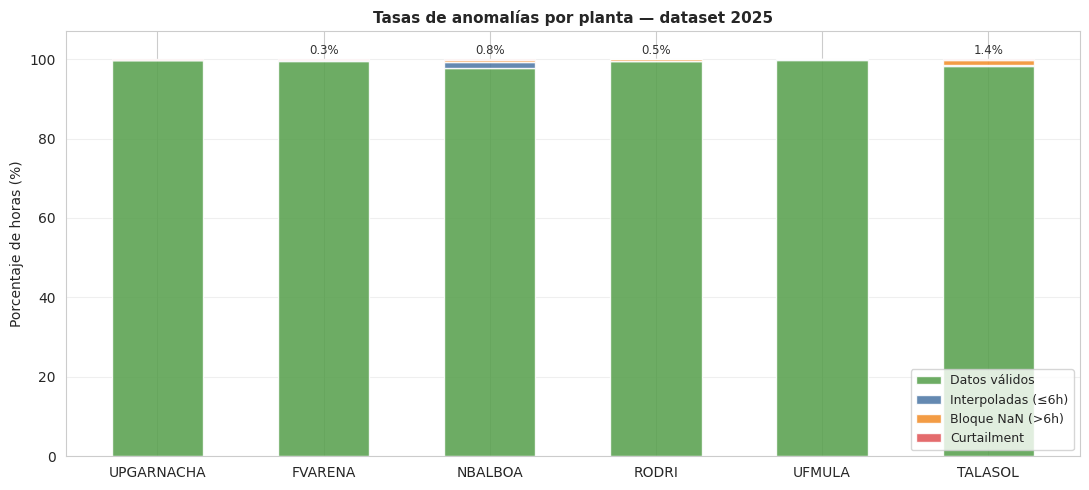

  Guardado: eda_anomaly_rates.png


In [9]:
# ── Celda 3d: Tabla de tasas de anomalías por planta ─────────────────────────
# Resumen cuantitativo de la calidad del dataset procesado.
# Tabla lista para incluir en la Sección 3.2 del TFM.
#
# Categorías (mutuamente excluyentes, suma = 100%):
#   curtailment  → valid_data=False, produccion=0   (eventos nacionales Apr 28, Jul 13)
#   bloque NaN   → valid_data=False, produccion=NaN (huecos >6h no imputables)
#   interpoladas → valid_data=True,  produccion=rec. (huecos ≤6h interpolados)
#   válidas      → valid_data=True,  produccion=original (sin ninguna intervención)

print('── Tabla 3.X — Tasas de anomalías del dataset por planta ──\n')

_rows = []
for planta in PLANTAS:
    df_p = df[df['planta_nombre'] == planta]
    _n   = len(df_p)

    _n_curt   = int(df_p['curtailment'].sum())
    _n_nan    = int(df_p['produccion'].isna().sum())          # bloques >6h
    _n_inv    = int((~df_p['valid_data'].fillna(True).astype(bool)).sum())  # = curt + nan

    # Interpoladas: de df_sum creado en celda 3c
    _row_sum  = df_sum[df_sum['Planta'] == planta]
    _n_interp = int(_row_sum['Interp (≤6h)'].values[0]) if len(_row_sum) > 0 else 0

    _n_valid  = _n - _n_inv - _n_interp   # horas completamente limpias

    _rows.append({
        'Planta':       planta,
        'Total h':      _n,
        'Válidas h':    _n_valid,
        '% válidas':    f'{_n_valid / _n * 100:.1f}',
        'Interp. h':    _n_interp,
        '% interp.':    f'{_n_interp / _n * 100:.2f}',
        'NaN h':        _n_nan,
        '% NaN':        f'{_n_nan / _n * 100:.2f}',
        'Curtail. h':   _n_curt,
        '% curtail.':   f'{_n_curt / _n * 100:.2f}',
        '% inválido':   f'{_n_inv / _n * 100:.2f}',
    })

df_anom_rates = pd.DataFrame(_rows)

_cols_print = ['Planta', 'Total h', '% válidas', '% interp.', '% NaN', '% curtail.', '% inválido']
print(df_anom_rates[_cols_print].to_string(index=False))

_tot = df_anom_rates[['Total h', 'Curtail. h', 'NaN h', 'Interp. h']].sum()
print(f'\n  Total horas  : {_tot["Total h"]:,}')
print(f'  Curtailment  : {_tot["Curtail. h"]:.0f} h  '
      f'({_tot["Curtail. h"] / _tot["Total h"] * 100:.2f}%)')
print(f'  Bloques NaN  : {_tot["NaN h"]:.0f} h  '
      f'({_tot["NaN h"] / _tot["Total h"] * 100:.2f}%)')
print(f'  Interpoladas : {_tot["Interp. h"]:.0f} h  '
      f'({_tot["Interp. h"] / _tot["Total h"] * 100:.2f}%)')

# ── Stacked bar chart ─────────────────────────────────────────────────────────
_n_arr    = df_anom_rates['Total h'].astype(float).values
_ok_arr   = df_anom_rates['Válidas h'].astype(float).values
_int_arr  = df_anom_rates['Interp. h'].astype(float).values
_nan_arr  = df_anom_rates['NaN h'].astype(float).values
_curt_arr = df_anom_rates['Curtail. h'].astype(float).values

_x = np.arange(len(PLANTAS))
_w = 0.55

fig, ax = plt.subplots(figsize=(11, 5))

_b0 = _ok_arr   / _n_arr * 100
_b1 = _int_arr  / _n_arr * 100
_b2 = _nan_arr  / _n_arr * 100
_b3 = _curt_arr / _n_arr * 100

ax.bar(_x, _b0, _w, label='Datos válidos',      color='#59A14F', alpha=0.88)
ax.bar(_x, _b1, _w, label='Interpoladas (≤6h)', color='#4E79A7', alpha=0.88,
       bottom=_b0)
ax.bar(_x, _b2, _w, label='Bloque NaN (>6h)',   color='#F28E2B', alpha=0.88,
       bottom=_b0 + _b1)
ax.bar(_x, _b3, _w, label='Curtailment',         color='#E15759', alpha=0.88,
       bottom=_b0 + _b1 + _b2)

# Anotar % inválido total encima de cada barra
for _xi, (_nan, _crt, _n) in enumerate(zip(_nan_arr, _curt_arr, _n_arr)):
    _pct_inv = (_nan + _crt) / _n * 100
    if _pct_inv > 0.1:
        ax.text(_xi, 100.5, f'{_pct_inv:.1f}%',
                ha='center', va='bottom', fontsize=8.5, color='#333333')

ax.set_xticks(_x)
ax.set_xticklabels(PLANTAS, fontsize=10)
ax.set_ylabel('Porcentaje de horas (%)', fontsize=10)
ax.set_title('Tasas de anomalías por planta — dataset 2025', fontsize=11, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.set_ylim(0, 107)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(fig_dir / 'eda_anomaly_rates.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'  Guardado: eda_anomaly_rates.png')

del _rows, _x, _w, _b0, _b1, _b2, _b3
del _n_arr, _ok_arr, _int_arr, _nan_arr, _curt_arr


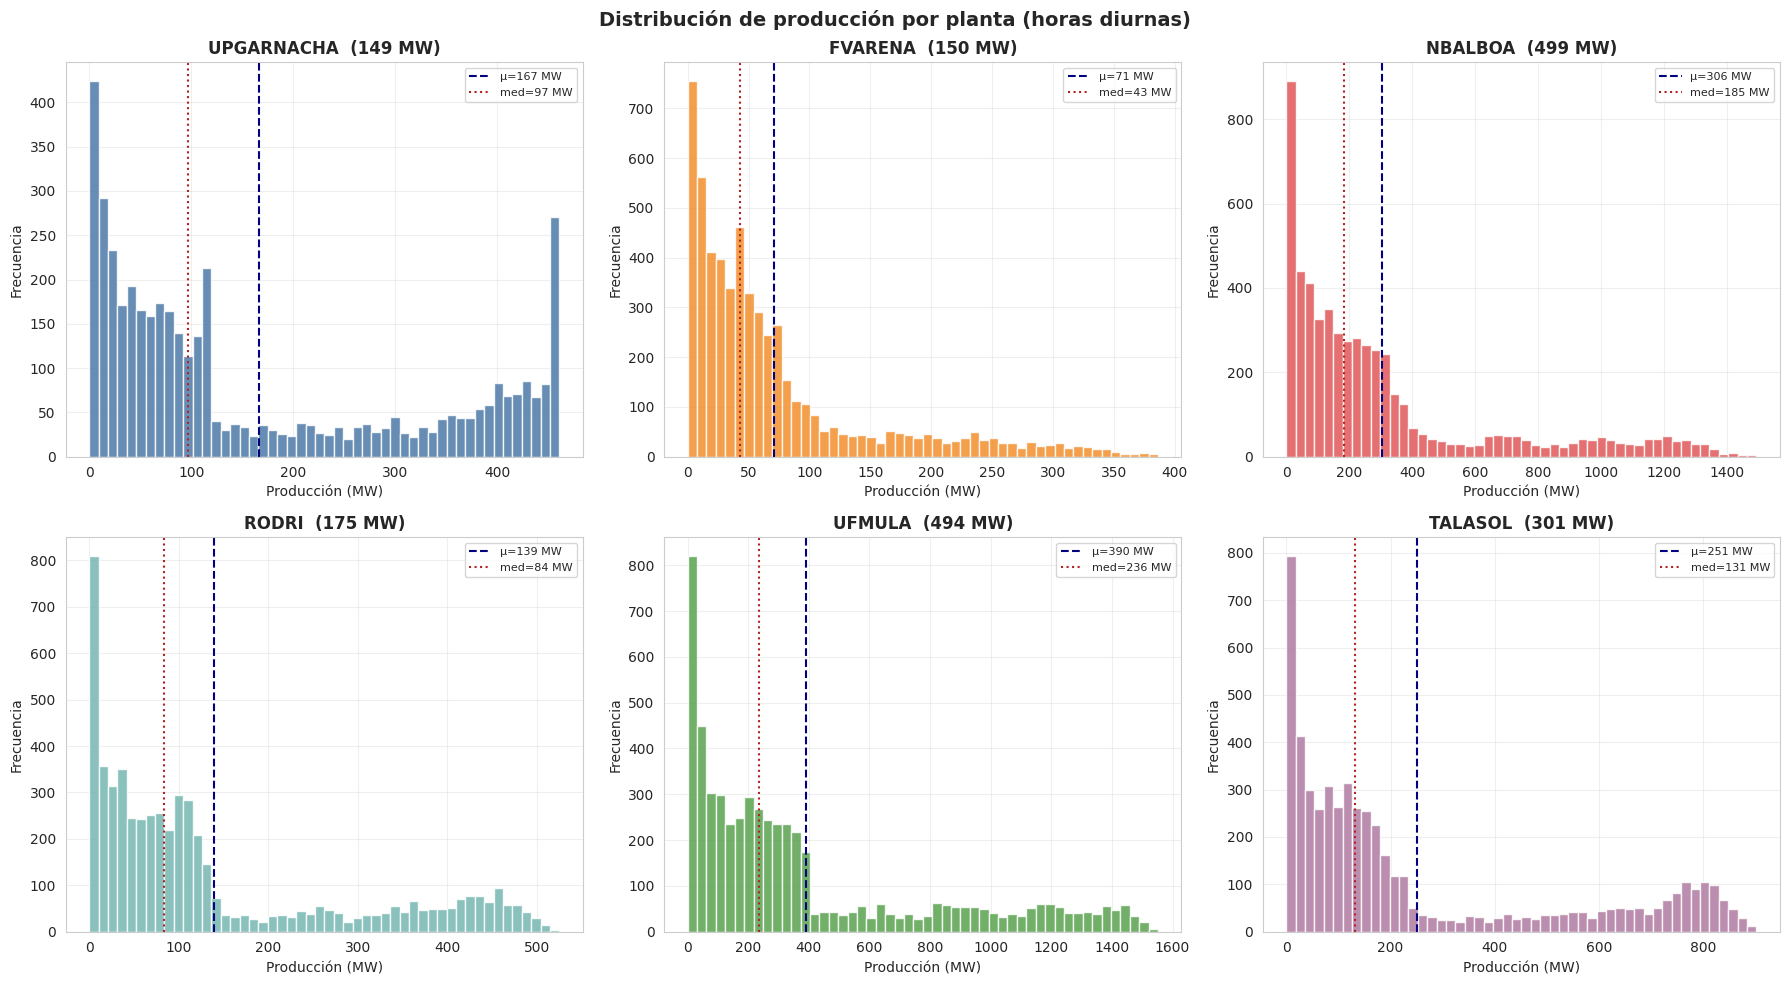

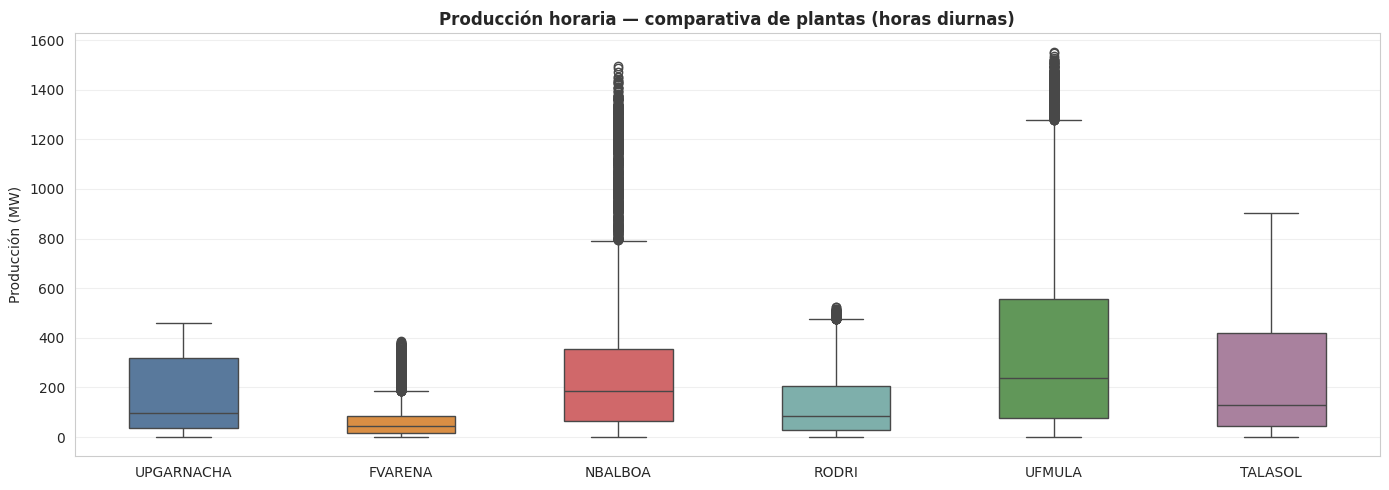

In [10]:
# ============================================================================
# CELDA 4 — EDA: Distribución de producción por planta
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribución de producción por planta (horas diurnas)', fontsize=14, fontweight='bold')

for ax, planta in zip(axes.flat, PLANTAS):
    df_p = df[(df['planta_nombre'] == planta) & (df['es_dia'] == 1)]
    if len(df_p) == 0:
        ax.set_visible(False)
        continue
    color = PALETTE.get(planta, '#888888')
    ax.hist(df_p['produccion'], bins=50, color=color, edgecolor='white', alpha=0.85)
    stats = df_p['produccion']
    ax.axvline(stats.mean(),   color='navy',   linestyle='--', linewidth=1.5,
               label=f'μ={stats.mean():.0f} MW')
    ax.axvline(stats.median(), color='firebrick', linestyle=':',  linewidth=1.5,
               label=f'med={stats.median():.0f} MW')
    mw = df_p['instalada_mw'].iloc[0]
    ax.set_title(f'{planta}  ({mw:.0f} MW)', fontweight='bold')
    ax.set_xlabel('Producción (MW)')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
fig_dir = RESULTS_DIR / 'figures' / 'eda'
fig_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_dir / 'eda_distribuciones_produccion.png', dpi=150, bbox_inches='tight')
plt.show()

# Boxplot comparativo
fig, ax = plt.subplots(figsize=(14, 5))
df_dia = df[df['es_dia'] == 1].copy()
df_dia['Planta'] = df_dia['planta_nombre']
sns.boxplot(
    data=df_dia[df_dia['planta_nombre'].isin(PLANTAS)],
    x='planta_nombre', y='produccion',
    order=PLANTAS,
    palette=PALETTE,
    ax=ax, width=0.5
)
ax.set_title('Producción horaria — comparativa de plantas (horas diurnas)', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Producción (MW)')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir / 'eda_boxplot_plantas.png', dpi=150, bbox_inches='tight')
plt.show()

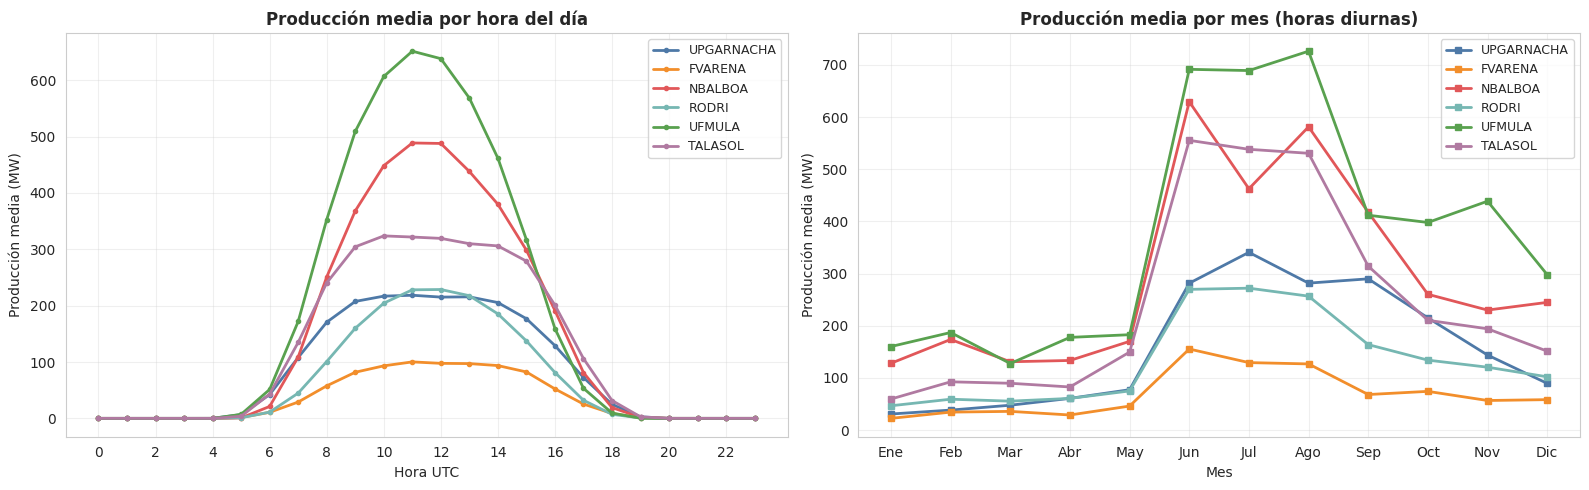

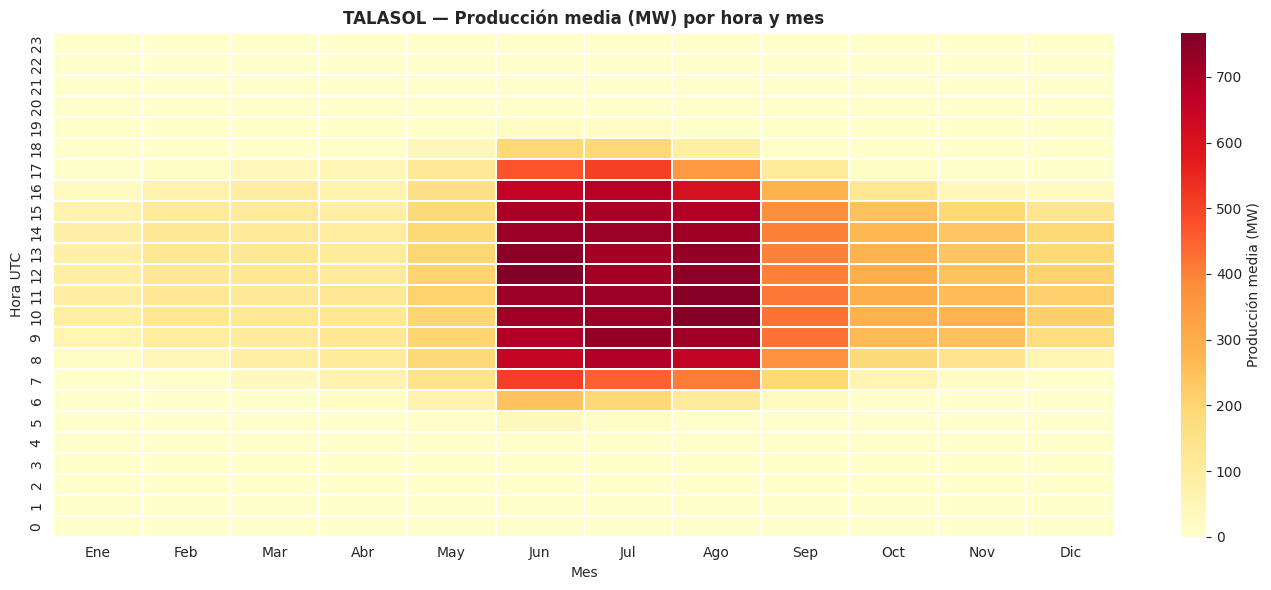

In [11]:
# ============================================================================
# CELDA 5 — EDA: Patrones temporales (hora del día, mes)
# ============================================================================

# ── 5a. Producción media por hora del día ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
for planta in PLANTAS:
    df_p = df[df['planta_nombre'] == planta]
    perfil = df_p.groupby('hora')['produccion'].mean()
    ax.plot(perfil.index, perfil.values,
            color=PALETTE.get(planta, '#888888'),
            linewidth=2, label=planta, marker='o', markersize=3)

ax.set_title('Producción media por hora del día', fontweight='bold')
ax.set_xlabel('Hora UTC')
ax.set_ylabel('Producción media (MW)')
ax.legend(fontsize=9, loc='upper right')
ax.set_xticks(range(0, 24, 2))
ax.grid(True, alpha=0.3)

# ── 5b. Producción media por mes ─────────────────────────────────────────────
ax = axes[1]
meses_nombres = ['Ene','Feb','Mar','Abr','May','Jun',
                 'Jul','Ago','Sep','Oct','Nov','Dic']
for planta in PLANTAS:
    df_p = df[(df['planta_nombre'] == planta) & (df['es_dia'] == 1)]
    perfil = df_p.groupby('mes')['produccion'].mean()
    ax.plot([meses_nombres[m-1] for m in perfil.index], perfil.values,
            color=PALETTE.get(planta, '#888888'),
            linewidth=2, label=planta, marker='s', markersize=4)

ax.set_title('Producción media por mes (horas diurnas)', fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Producción media (MW)')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(fig_dir / 'eda_patrones_temporales.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 5c. Heatmap hora × mes para TALASOL (plant target) ───────────────────────
df_ts = df[df['planta_nombre'] == 'TALASOL'].copy()
pivot = df_ts.pivot_table(values='produccion', index='hora', columns='mes', aggfunc='mean')
pivot.columns = [meses_nombres[m-1] for m in pivot.columns]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    pivot, cmap='YlOrRd', ax=ax,
    linewidths=0.3, linecolor='white',
    cbar_kws={'label': 'Producción media (MW)'}
)
ax.set_title('TALASOL — Producción media (MW) por hora y mes', fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Hora UTC')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(fig_dir / 'eda_heatmap_hora_mes_TALASOL.png', dpi=150, bbox_inches='tight')
plt.show()

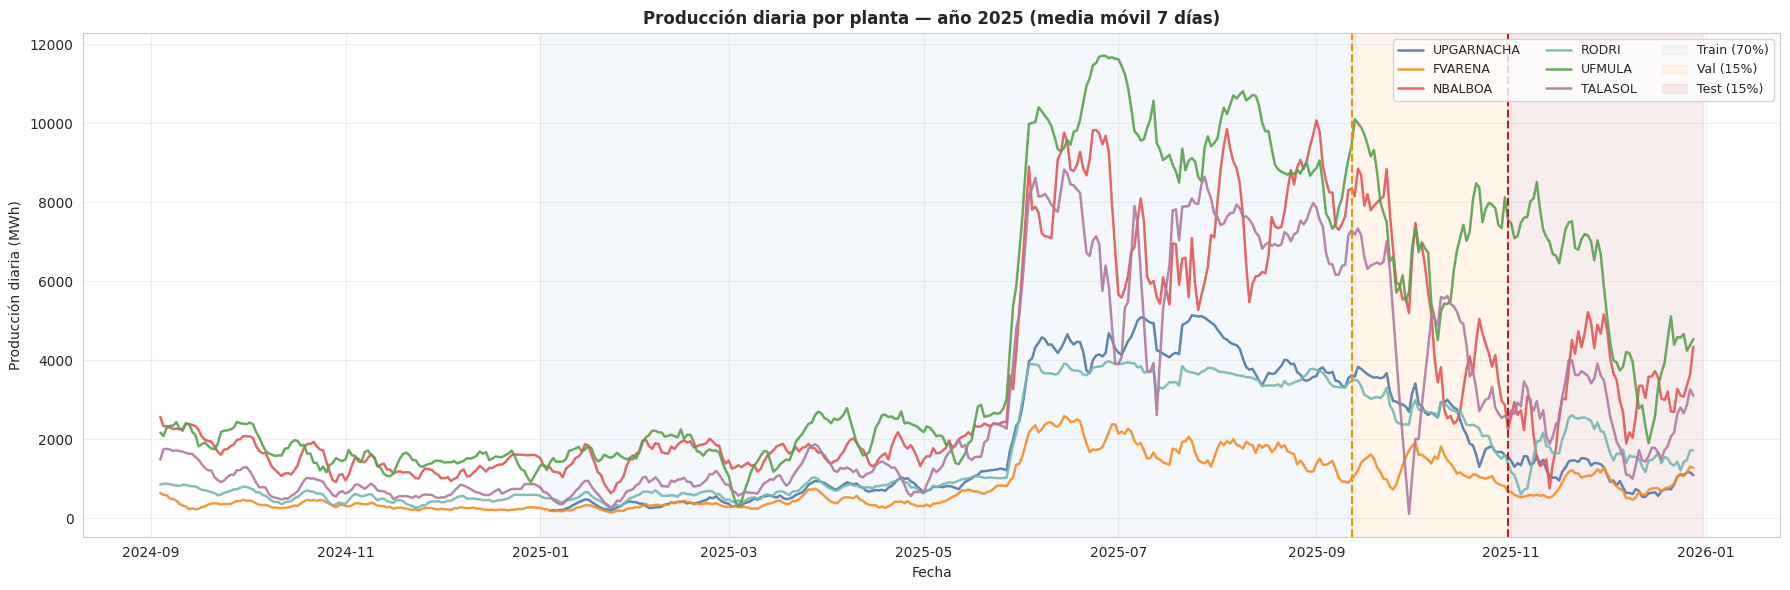

In [12]:
# ============================================================================
# CELDA 6 — EDA: Series temporales (visión anual)
# ============================================================================

# Producción diaria agregada por planta
df_diario = (
    df.copy()
    .assign(fecha=lambda x: pd.to_datetime(x['timestamp_utc']).dt.date)
    .groupby(['fecha', 'planta_nombre'])['produccion']
    .sum()   # MWh/día
    .reset_index()
)
df_diario['fecha'] = pd.to_datetime(df_diario['fecha'])

fig, ax = plt.subplots(figsize=(18, 6))
for planta in PLANTAS:
    df_p = df_diario[df_diario['planta_nombre'] == planta].sort_values('fecha')
    # Rolling 7 días para suavizar
    prod_smooth = df_p.set_index('fecha')['produccion'].rolling(7, center=True).mean()
    ax.plot(prod_smooth.index, prod_smooth.values,
            color=PALETTE.get(planta, '#888888'),
            linewidth=1.8, label=planta, alpha=0.9)

# Añadir zonas de split
split_train = pd.Timestamp('2025-09-12')
split_val   = pd.Timestamp('2025-10-31')
ymin, ymax = ax.get_ylim()
ax.axvspan(pd.Timestamp('2025-01-01'), split_train,
           alpha=0.05, color='steelblue', label='Train (70%)')
ax.axvspan(split_train, split_val,
           alpha=0.08, color='darkorange', label='Val (15%)')
ax.axvspan(split_val, pd.Timestamp('2025-12-31'),
           alpha=0.08, color='firebrick', label='Test (15%)')
ax.axvline(split_train, color='darkorange', linestyle='--', linewidth=1.5)
ax.axvline(split_val,   color='firebrick',  linestyle='--', linewidth=1.5)

ax.set_title('Producción diaria por planta — año 2025 (media móvil 7 días)', fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Producción diaria (MWh)')
ax.legend(ncol=3, fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir / 'eda_series_anuales.png', dpi=150, bbox_inches='tight')
plt.show()

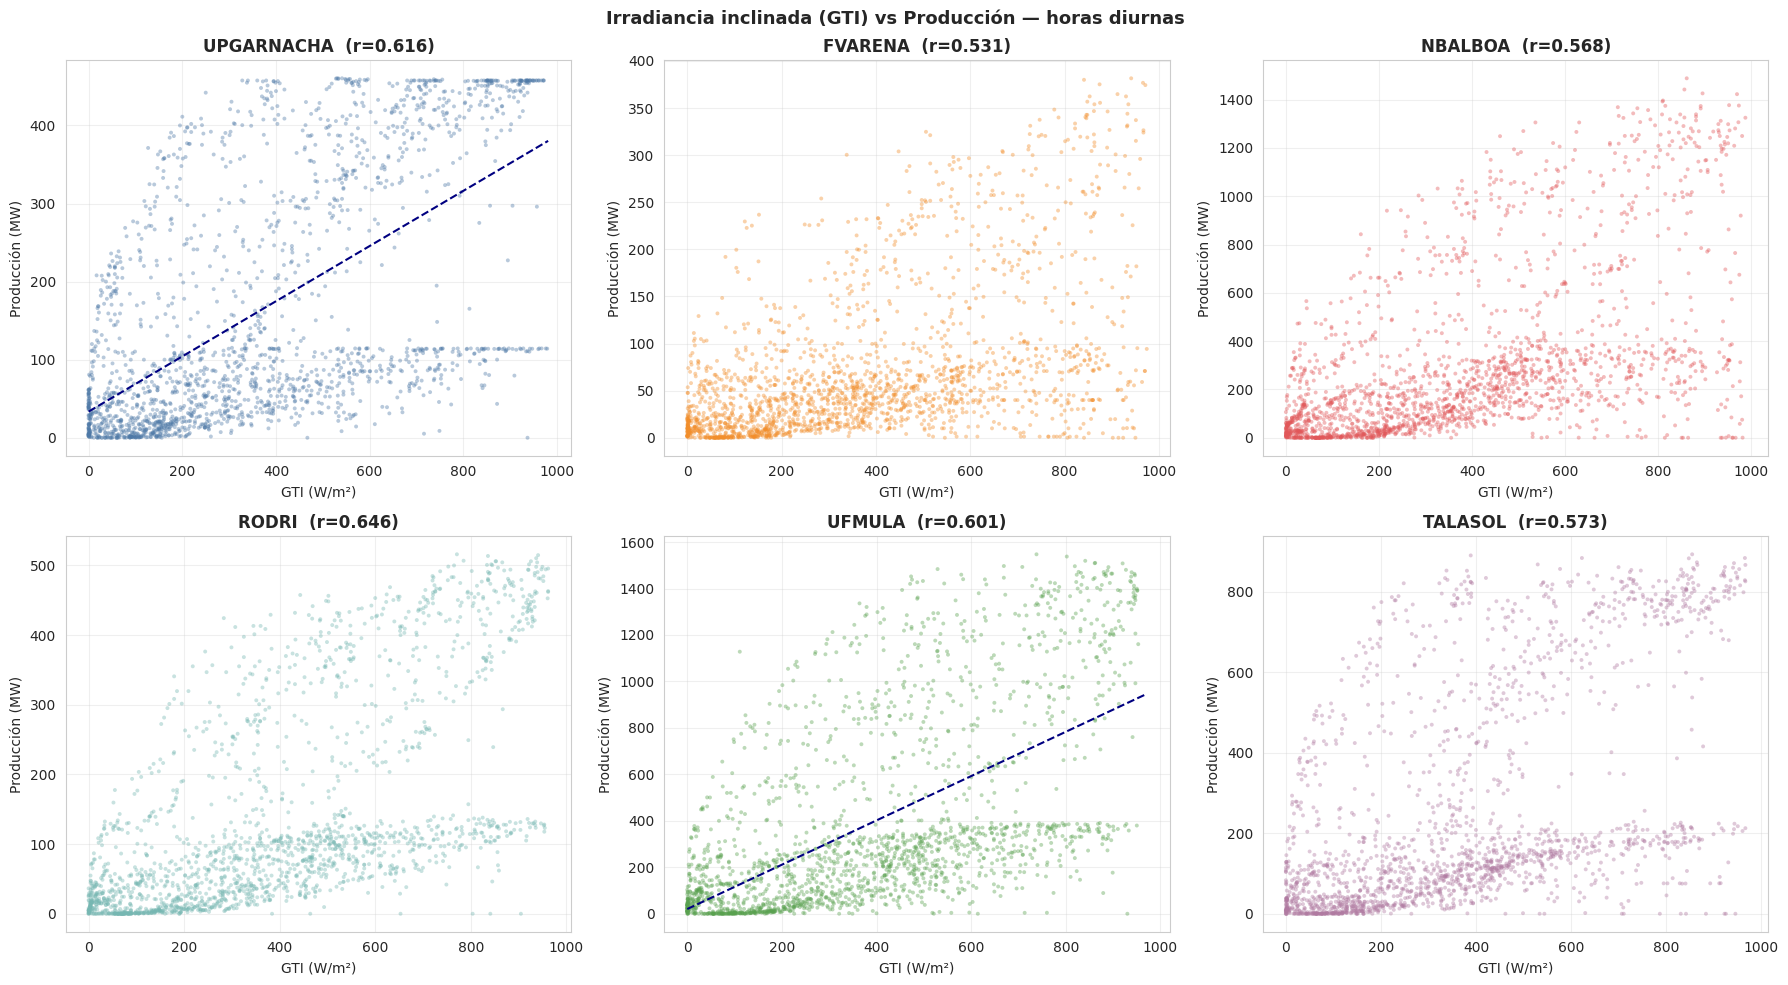

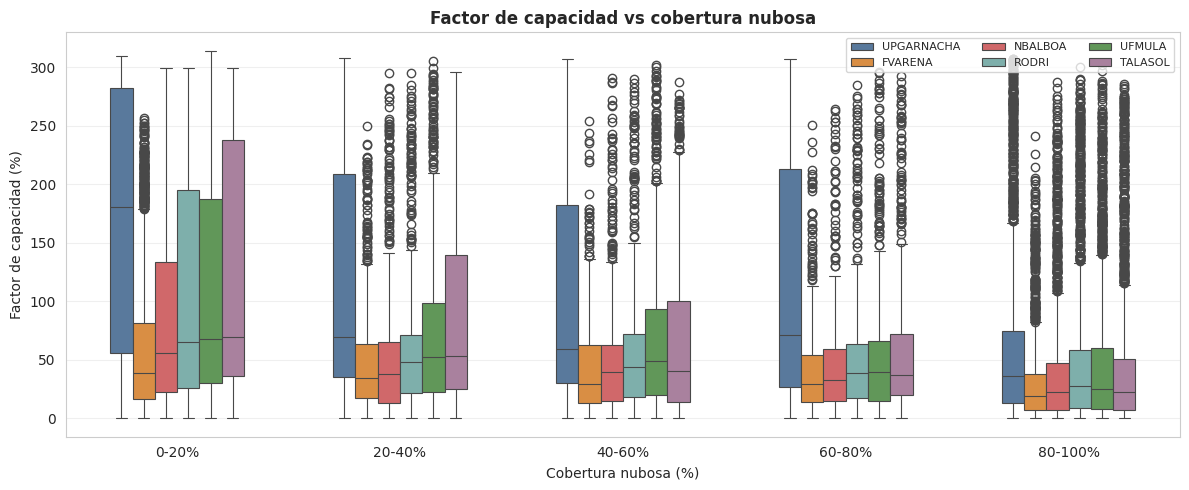

In [13]:
# ============================================================================
# CELDA 7 — EDA: Irradiancia vs producción y análisis meteorológico
# ============================================================================

# ── 7a. Scatter irradiancia vs producción (horas diurnas) ────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Irradiancia inclinada (GTI) vs Producción — horas diurnas', fontsize=13, fontweight='bold')

for ax, planta in zip(axes.flat, PLANTAS):
    df_p = df[(df['planta_nombre'] == planta) & (df['es_dia'] == 1)]
    if len(df_p) == 0:
        ax.set_visible(False)
        continue
    color = PALETTE.get(planta, '#888888')
    # Subsample para no saturar el scatter
    df_s = df_p.sample(min(2000, len(df_p)), random_state=42)
    ax.scatter(df_s['global_tilted_irradiance'], df_s['produccion'],
               c=color, alpha=0.4, s=8, edgecolors='none')
    # Línea de regresión simple
    z = np.polyfit(df_p['global_tilted_irradiance'].dropna(),
                   df_p.loc[df_p['global_tilted_irradiance'].notna(), 'produccion'], 1)
    p = np.poly1d(z)
    x_fit = np.linspace(0, df_p['global_tilted_irradiance'].max(), 100)
    ax.plot(x_fit, p(x_fit), color='navy', linewidth=1.5, linestyle='--')
    # Correlación
    corr = df_p[['global_tilted_irradiance','produccion']].corr().iloc[0,1]
    ax.set_title(f'{planta}  (r={corr:.3f})', fontweight='bold')
    ax.set_xlabel('GTI (W/m²)')
    ax.set_ylabel('Producción (MW)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(fig_dir / 'eda_irradiancia_produccion.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 7b. Impacto de la nubosidad ───────────────────────────────────────────────
df_dia_all = df[(df['es_dia'] == 1) & (df['planta_nombre'].isin(PLANTAS))].copy()
df_dia_all['nubosidad_cat'] = pd.cut(
    df_dia_all['cloud_cover'],
    bins=[0, 20, 40, 60, 80, 100],
    labels=['0-20%','20-40%','40-60%','60-80%','80-100%'],
    include_lowest=True
)
# Normalizar por capacidad para hacer plantas comparables
df_dia_all['cf'] = df_dia_all['produccion'] / df_dia_all['instalada_mw'] * 100

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(
    data=df_dia_all, x='nubosidad_cat', y='cf',
    hue='planta_nombre', hue_order=PLANTAS,
    palette=PALETTE, ax=ax, width=0.6, linewidth=0.8
)
ax.set_title('Factor de capacidad vs cobertura nubosa', fontweight='bold')
ax.set_xlabel('Cobertura nubosa (%)')
ax.set_ylabel('Factor de capacidad (%)')
ax.legend(fontsize=8, ncol=3, loc='upper right')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir / 'eda_nubosidad_cf.png', dpi=150, bbox_inches='tight')
plt.show()

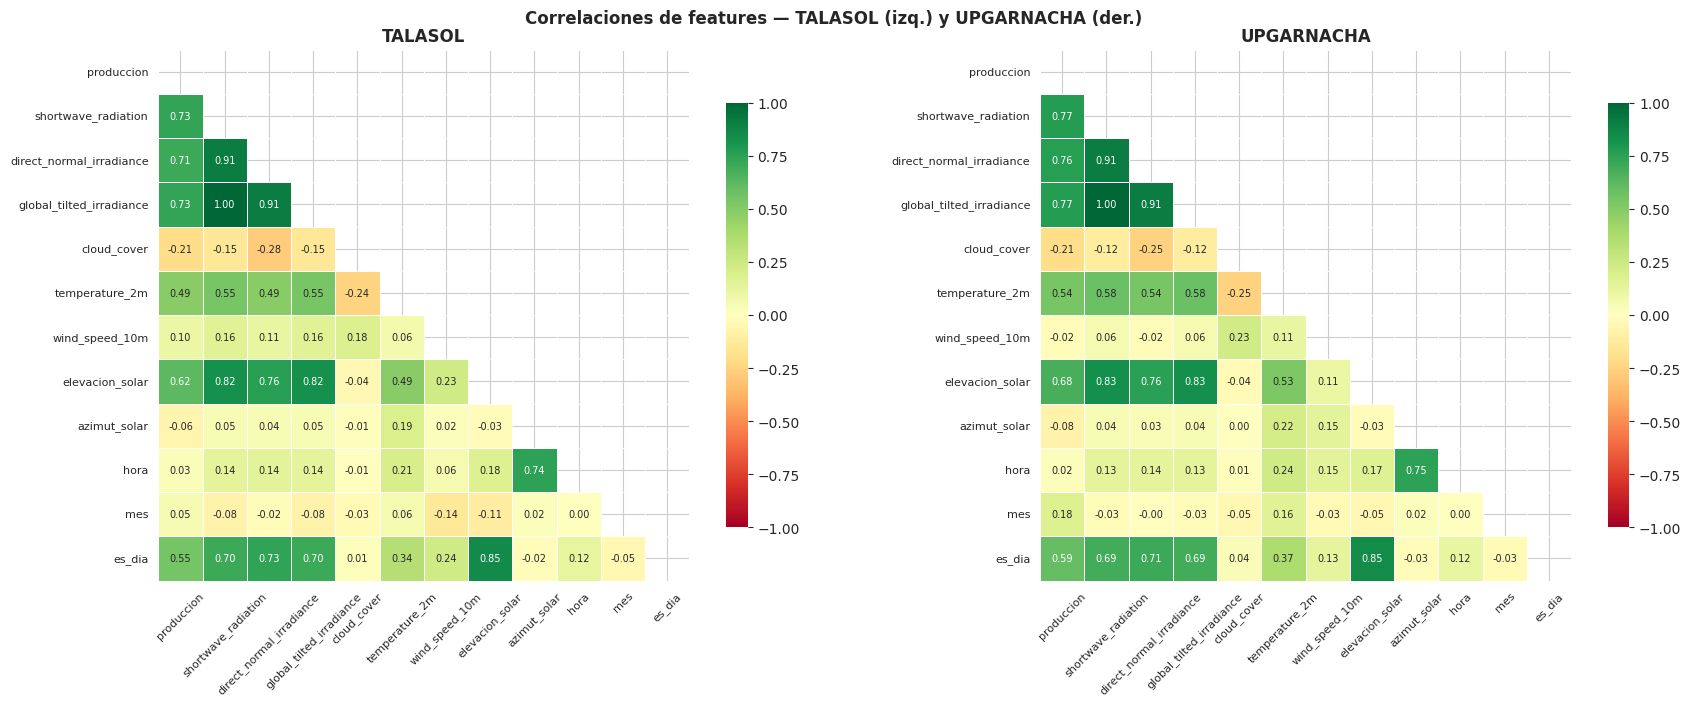

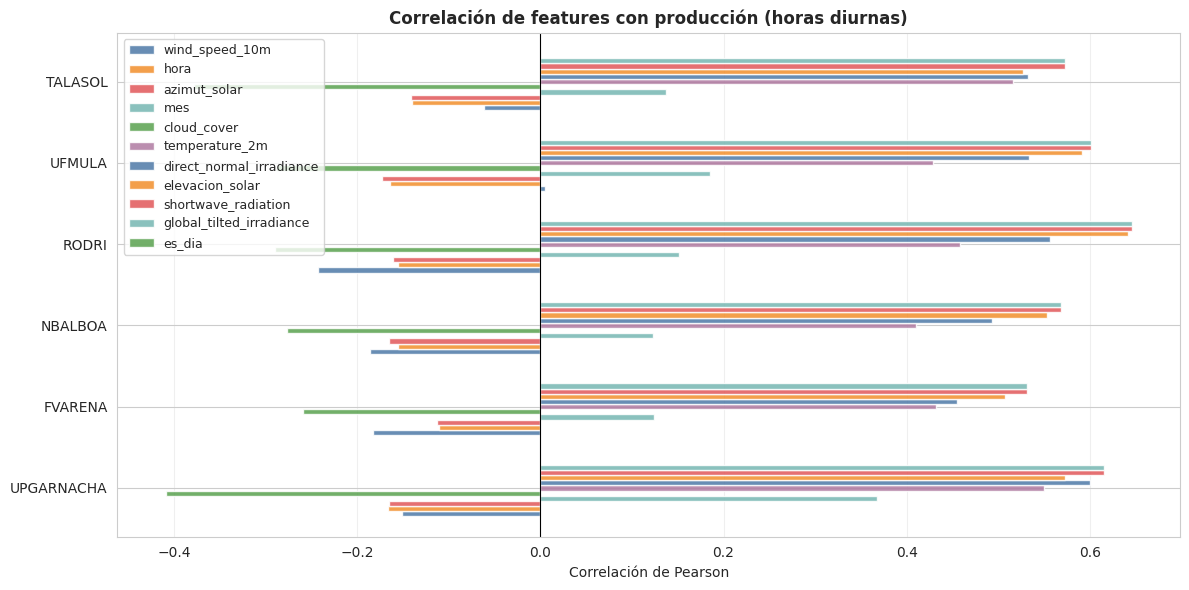

In [14]:
# ============================================================================
# CELDA 8 — EDA: Correlaciones entre variables (TALASOL como ejemplo)
# ============================================================================

FEATURE_COLS = [
    'produccion',
    'shortwave_radiation', 'direct_normal_irradiance', 'global_tilted_irradiance',
    'cloud_cover', 'temperature_2m', 'wind_speed_10m',
    'elevacion_solar', 'azimut_solar',
    'hora', 'mes', 'es_dia',
]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Correlaciones de features — TALASOL (izq.) y UPGARNACHA (der.)',
             fontsize=12, fontweight='bold')

for ax, planta in zip(axes, ['TALASOL', 'UPGARNACHA']):
    df_p = df[df['planta_nombre'] == planta]
    cols_ok = [c for c in FEATURE_COLS if c in df_p.columns]
    corr = df_p[cols_ok].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(
        corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
        vmin=-1, vmax=1, center=0, square=True,
        linewidths=0.4, cbar_kws={'shrink': 0.8},
        annot_kws={'size': 7}, ax=ax
    )
    ax.set_title(planta, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

plt.tight_layout()
plt.savefig(fig_dir / 'eda_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Bar chart de correlación con producción ────────────────────────────────────
corr_prod = {}
for planta in PLANTAS:
    df_p = df[(df['planta_nombre'] == planta) & (df['es_dia'] == 1)]
    feat = [c for c in FEATURE_COLS if c in df_p.columns and c != 'produccion']
    c = df_p[feat + ['produccion']].corr()['produccion'].drop('produccion')
    corr_prod[planta] = c

df_corr = pd.DataFrame(corr_prod)
df_corr_sorted = df_corr.abs().mean(axis=1).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
df_corr.loc[df_corr_sorted.index].T.plot(
    kind='barh', ax=ax, width=0.7,
    color=[PALETTE.get(p, '#888888') for p in PLANTAS],
    alpha=0.85, legend=True
)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación de features con producción (horas diurnas)', fontweight='bold')
ax.set_xlabel('Correlación de Pearson')
ax.grid(True, axis='x', alpha=0.3)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(fig_dir / 'eda_correlacion_features.png', dpi=150, bbox_inches='tight')
plt.show()

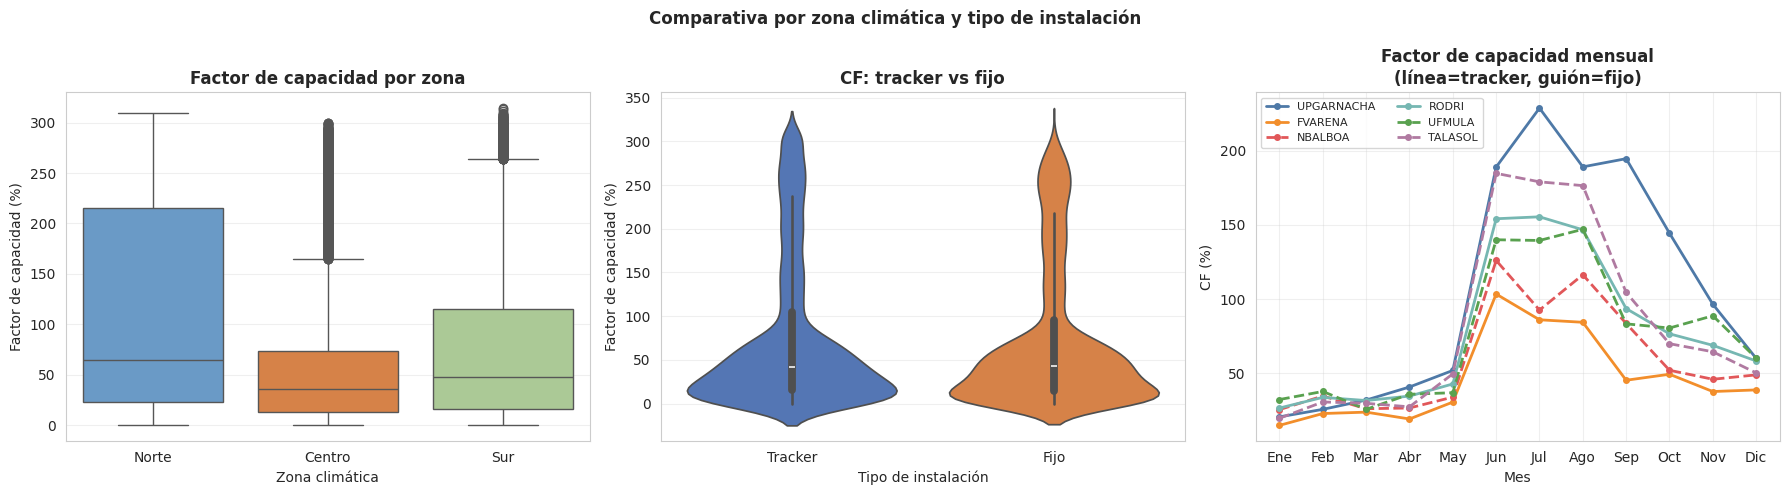


CF medio anual por planta:
               CF_medio  CF_max    Zona     Tipo
planta_nombre                                   
UPGARNACHA      112.010 309.530   Norte  Tracker
FVARENA          47.430 257.070  Centro  Tracker
NBALBOA          61.310 299.350  Centro     Fijo
RODRI            79.420 300.340     Sur  Tracker
UFMULA           78.960 314.340     Sur     Fijo
TALASOL          83.570 299.920  Centro     Fijo


In [15]:
# ============================================================================
# CELDA 9 — EDA: Comparación entre zonas y tipos de instalación
# ============================================================================

df_dia_all = df[(df['es_dia'] == 1) & (df['planta_nombre'].isin(PLANTAS))].copy()
df_dia_all['cf'] = df_dia_all['produccion'] / df_dia_all['instalada_mw'] * 100
df_dia_all['tipo_instalacion'] = df_dia_all['seguimiento'].map({1: 'Tracker', 0: 'Fijo'})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Comparativa por zona climática y tipo de instalación', fontsize=12, fontweight='bold')

# ── Factor de capacidad por zona ──────────────────────────────────────────────
ax = axes[0]
sns.boxplot(
    data=df_dia_all, x='zona_climatica', y='cf',
    order=['Norte', 'Centro', 'Sur'],
    palette={'Norte': '#5B9BD5', 'Centro': '#ED7D31', 'Sur': '#A9D18E'},
    ax=ax
)
ax.set_title('Factor de capacidad por zona', fontweight='bold')
ax.set_xlabel('Zona climática')
ax.set_ylabel('Factor de capacidad (%)')
ax.grid(True, axis='y', alpha=0.3)

# ── CF por tipo de instalación ────────────────────────────────────────────────
ax = axes[1]
sns.violinplot(
    data=df_dia_all, x='tipo_instalacion', y='cf',
    palette={'Tracker': '#4472C4', 'Fijo': '#ED7D31'},
    inner='box', ax=ax
)
ax.set_title('CF: tracker vs fijo', fontweight='bold')
ax.set_xlabel('Tipo de instalación')
ax.set_ylabel('Factor de capacidad (%)')
ax.grid(True, axis='y', alpha=0.3)

# ── CF mensual por planta ─────────────────────────────────────────────────────
ax = axes[2]
meses_nombres = ['Ene','Feb','Mar','Abr','May','Jun',
                 'Jul','Ago','Sep','Oct','Nov','Dic']
for planta in PLANTAS:
    df_p = df_dia_all[df_dia_all['planta_nombre'] == planta]
    cf_mes = df_p.groupby('mes')['cf'].mean()
    ls = '-' if df_p['seguimiento'].iloc[0] == 1 else '--'
    ax.plot([meses_nombres[m-1] for m in cf_mes.index], cf_mes.values,
            color=PALETTE.get(planta, '#888888'),
            linewidth=2, label=planta, linestyle=ls, marker='o', markersize=4)

ax.set_title('Factor de capacidad mensual\n(línea=tracker, guión=fijo)', fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('CF (%)')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(fig_dir / 'eda_zonas_tipos.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabla resumen
print('\nCF medio anual por planta:')
resumen_cf = df_dia_all.groupby('planta_nombre').agg(
    CF_medio=('cf', 'mean'),
    CF_max=('cf', 'max'),
    Zona=('zona_climatica', 'first'),
    Tipo=('tipo_instalacion', 'first'),
).round(2)
print(resumen_cf.loc[PLANTAS].to_string())

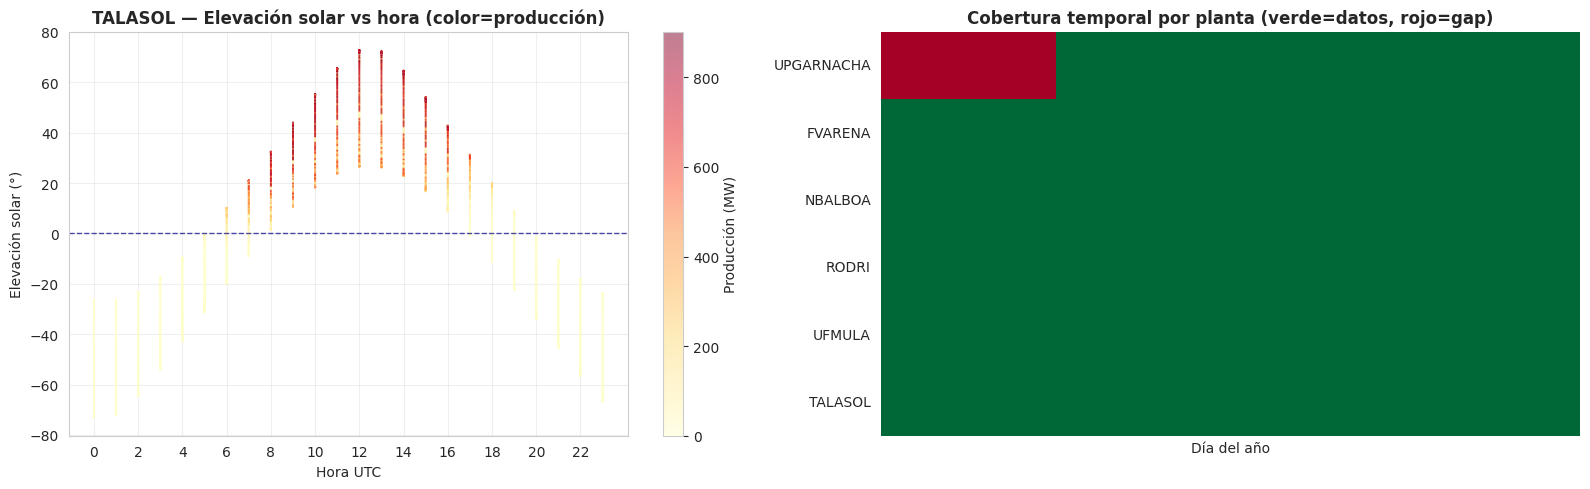

In [16]:
# ============================================================================
# CELDA 10 — EDA: Posición solar y análisis de datos faltantes
# ============================================================================

# ── 10a. Diagrama de posición solar (elevación vs hora del día) ───────────────
df_ts = df[df['planta_nombre'] == 'TALASOL'].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
scatter = ax.scatter(
    df_ts['hora'], df_ts['elevacion_solar'],
    c=df_ts['produccion'], cmap='YlOrRd',
    s=2, alpha=0.5, edgecolors='none'
)
plt.colorbar(scatter, ax=ax, label='Producción (MW)')
ax.axhline(0, color='navy', linewidth=1, linestyle='--', alpha=0.7)
ax.set_title('TALASOL — Elevación solar vs hora (color=producción)', fontweight='bold')
ax.set_xlabel('Hora UTC')
ax.set_ylabel('Elevación solar (°)')
ax.set_xticks(range(0, 24, 2))
ax.grid(True, alpha=0.3)

# ── 10b. Heatmap de continuidad temporal (gaps) ───────────────────────────────
ax = axes[1]

pivot_dia = (
    df[df['planta_nombre'].isin(PLANTAS)]
    .assign(fecha=lambda x: pd.to_datetime(x['timestamp_utc']).dt.date)
    .groupby(['planta_nombre', 'fecha'])
    .size()
    .rename('n_registros')
    .reset_index()
    .pivot(index='planta_nombre', columns='fecha', values='n_registros')
    .reindex(PLANTAS)
)

# Submuestrear meses para visualización
fechas = pivot_dia.columns
idx_meses = [i for i, f in enumerate(fechas) if f.day == 1]

sns.heatmap(
    pivot_dia.notna().astype(int),
    ax=ax, cmap='RdYlGn', cbar=False,
    xticklabels=False, yticklabels=True,
    linewidths=0, vmin=0, vmax=1
)
ax.set_title('Cobertura temporal por planta (verde=datos, rojo=gap)', fontweight='bold')
ax.set_xlabel('Día del año')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig(fig_dir / 'eda_solar_continuidad.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# ============================================================================
# CELDA 11 — División temporal train / val / test
# ============================================================================
# Fechas de corte fijas (independientes del volumen total):
#   Train : Sep 2024 – 12 Sep 2025  (todo el histórico disponible)
#   Val   : 13 Sep   – 31 Oct 2025
#   Test  : 1 Nov    – 31 Dic 2025  (periodo de evaluación fijo)
#
# UPGARNACHA solo tiene datos 2025 → su train empieza en Ene 2025.
# Las demás plantas tienen train desde Sep 2024.

TRAIN_END = '2025-09-12'
VAL_END   = '2025-10-31'

df_train, df_val, df_test = processor.split_train_val_test(
    df,
    train_end=TRAIN_END,
    val_end=VAL_END
)

print(f'\n--- Verificación de splits ---')
for name, split in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    plantas_ok = sorted(split['planta_nombre'].unique())
    print(f'{name:6}: {len(split):7,} registros | plantas={plantas_ok}')
    ts = split['timestamp_utc'] if 'timestamp_utc' in split.columns else split['timestamp']
    ts = pd.to_datetime(ts)
    print(f'         periodo: {ts.min().date()} → {ts.max().date()}')



DIVISIÓN TEMPORAL DEL DATASET (2024-2025)

Train: 50,917 registros (76.4%)
  Periodo: 2024-09-01 a 2025-09-12
  Meses:   12.4

Val:   6,780 registros (10.2%)
  Periodo: 2025-09-12 a 2025-10-31
  Meses:   1.6

Test:  8,922 registros (13.4%)
  Periodo: 2025-10-31 a 2025-12-31
  Meses:   2.0

--------------------------------------------------------------------------------
NOTA METODOLÓGICA:
División temporal fija: val=Sep-Oct 2025, test=Nov-Dic 2025.
El train incluye datos desde Sep 2024 para plantas con datos de 2024.
UPGARNACHA solo dispone de datos 2025 (limitación documentada).
--------------------------------------------------------------------------------

--- Verificación de splits ---
Train :  50,917 registros | plantas=['FVARENA', 'NBALBOA', 'RODRI', 'TALASOL', 'UFMULA', 'UPGARNACHA']
         periodo: 2024-09-01 → 2025-09-12
Val   :   6,780 registros | plantas=['FVARENA', 'NBALBOA', 'RODRI', 'TALASOL', 'UFMULA', 'UPGARNACHA']
         periodo: 2025-09-12 → 2025-10-31
Test  :   

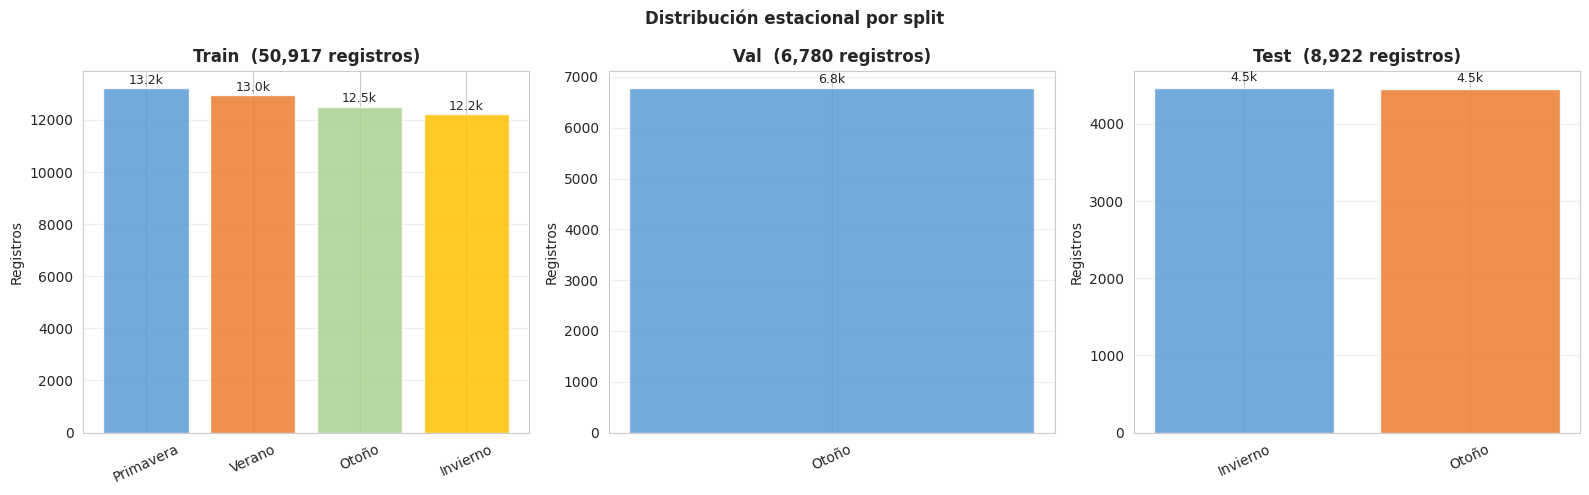


Registros por planta y split (solo plantas del experimento):
    Planta  Train  Val  Test  Total  %_Train
UPGARNACHA   6050 1130  1487   8667   69.800
   FVARENA   8978 1130  1487  11595   77.400
   NBALBOA   8955 1130  1487  11572   77.400
     RODRI   8978 1130  1487  11595   77.400
    UFMULA   8978 1130  1487  11595   77.400
   TALASOL   8978 1130  1487  11595   77.400

Producción media diurna por split y planta (MW):
    Planta   Train     Val    Test
UPGARNACHA 162.070 250.140 116.400
   FVARENA  64.000 114.460  87.020
   NBALBOA 277.030 501.210 347.670
     RODRI 122.130 238.440 176.270
    UFMULA 331.420 662.430 588.880
   TALASOL 228.610 422.310 269.720


In [18]:
# ============================================================================
# CELDA 12 — Análisis de cobertura estacional en los splits
# ============================================================================

# ── 12a. Distribución estacional ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribución estacional por split', fontsize=12, fontweight='bold')

for ax, (name, split) in zip(axes, [('Train', df_train), ('Val', df_val), ('Test', df_test)]):
    counts = split['estacion'].value_counts()
    bars = ax.bar(counts.index, counts.values,
                  color=['#5B9BD5','#ED7D31','#A9D18E','#FFC000'][:len(counts)],
                  edgecolor='white', alpha=0.85)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{val/1000:.1f}k', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'{name}  ({len(split):,} registros)', fontweight='bold')
    ax.set_ylabel('Registros')
    ax.set_xlabel('')
    ax.grid(True, axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig(fig_dir / 'eda_splits_estacional.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 12b. Registros por planta y split ────────────────────────────────────────
print('\nRegistros por planta y split (solo plantas del experimento):')
tabla = []
for planta in PLANTAS:
    tabla.append({
        'Planta': planta,
        'Train':  (df_train['planta_nombre'] == planta).sum(),
        'Val':    (df_val['planta_nombre']   == planta).sum(),
        'Test':   (df_test['planta_nombre']  == planta).sum(),
        'Total':  (df['planta_nombre']       == planta).sum(),
    })
df_tabla = pd.DataFrame(tabla)
df_tabla['%_Train'] = (df_tabla['Train'] / df_tabla['Total'] * 100).round(1)
print(df_tabla.to_string(index=False))

# ── 12c. Producción media en cada split (sanity check) ────────────────────────
print('\nProducción media diurna por split y planta (MW):')
tabla2 = []
for planta in PLANTAS:
    row = {'Planta': planta}
    for name, split in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
        mask = (split['planta_nombre'] == planta) & (split['es_dia'] == 1)
        row[name] = round(float(split.loc[mask, 'produccion'].mean()), 2) if mask.sum() > 0 else float('nan')
    tabla2.append(row)
print(pd.DataFrame(tabla2).to_string(index=False))

── Test KS — distribución train vs val y train vs test ──
  H₀: misma distribución continua subyacente  |  umbral α = 0.05

  Feature                           KS(tr,val)   p(tr,val)            KS(tr,test)  p(tr,test)          
  -----------------------------------------------------------------------------------------------
  Producción (MW) [diurnas]              0.288      0.0000   ⚠ SHIFT        0.130      0.0000   ⚠ SHIFT
  GTI (W/m²)                             0.055      0.0000   ⚠ SHIFT        0.160      0.0000   ⚠ SHIFT
  Nubosidad (%)                          0.058      0.0000   ⚠ SHIFT        0.186      0.0000   ⚠ SHIFT
  Temperatura (°C)                       0.304      0.0000   ⚠ SHIFT        0.429      0.0000   ⚠ SHIFT


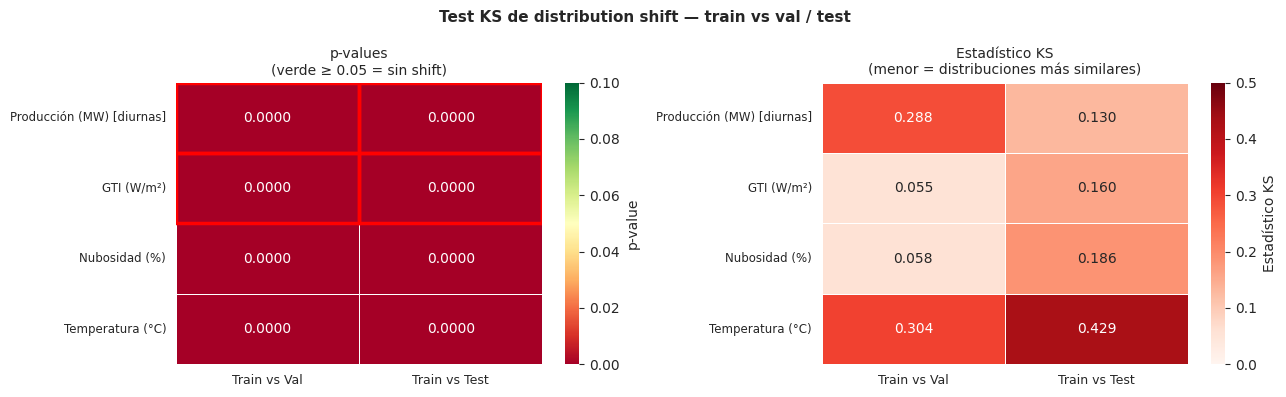

  Guardado: eda_ks_test.png

── Interpretación ──
  Features con shift train→val  : 4/4
  Features con shift train→test : 4/4
  Features afectadas: ['Producción (MW) [diurnas]', 'GTI (W/m²)', 'Nubosidad (%)', 'Temperatura (°C)']
  → Shift estacional esperado (train: ene–sep vs test: nov–dic).
  → Se documenta como limitación del split temporal en la sección 3.3.


In [19]:
# ── Celda 12b: Test KS — validación de distribution shift entre splits ────────
# El test de Kolmogorov-Smirnov evalúa si dos muestras siguen la misma
# distribución continua subyacente. H₀: misma distribución. p < 0.05 → shift.
#
# Relevancia metodológica:
#   Un shift severo en las features de entrada invalida la interpretación de las
#   métricas del test set (el modelo evalúa sobre una distribución no vista).
#   El shift en irradiancia y temperatura es ESPERADO (split temporal: train=verano,
#   test=invierno) y se documenta como limitación inherente del diseño experimental.
#
# Features analizadas: produccion (diurnas), GTI, nubosidad, temperatura.

from scipy.stats import ks_2samp

FEATURES_KS = {
    'produccion':               'Producción (MW) [diurnas]',
    'global_tilted_irradiance': 'GTI (W/m²)',
    'cloud_cover':              'Nubosidad (%)',
    'temperature_2m':           'Temperatura (°C)',
}

print('── Test KS — distribución train vs val y train vs test ──')
print(f'  H₀: misma distribución continua subyacente  |  umbral α = 0.05\n')
print(f'  {"Feature":<32} {"KS(tr,val)":>11} {"p(tr,val)":>11} {"":>9} '
      f'{"KS(tr,test)":>12} {"p(tr,test)":>11} {"":>9}')
print('  ' + '-' * 95)

_results_ks = []
for col, label in FEATURES_KS.items():
    # Producción: solo horas diurnas (nocturnas siempre 0 → sesgan el test)
    if col == 'produccion':
        _mask_v = df_train['es_dia'] == 1
        _tr = df_train.loc[_mask_v & df_train['valid_data'].fillna(True).astype(bool), col].dropna().values
        _va = df_val.loc[df_val['es_dia'] == 1, col].dropna().values
        _te = df_test.loc[df_test['es_dia'] == 1, col].dropna().values
    else:
        _tr = df_train[col].dropna().values
        _va = df_val[col].dropna().values
        _te = df_test[col].dropna().values

    _ks_tv, _p_tv = ks_2samp(_tr, _va)
    _ks_tt, _p_tt = ks_2samp(_tr, _te)

    _flag_tv = 'OK    ' if _p_tv >= 0.05 else '⚠ SHIFT'
    _flag_tt = 'OK    ' if _p_tt >= 0.05 else '⚠ SHIFT'

    print(f'  {label:<32} {_ks_tv:>11.3f} {_p_tv:>11.4f} {_flag_tv:>9} '
          f'{_ks_tt:>12.3f} {_p_tt:>11.4f} {_flag_tt:>9}')

    _results_ks.append({
        'Feature':        label,
        'KS(tr,val)':     round(_ks_tv, 3),
        'p(tr,val)':      round(_p_tv, 4),
        'shift_tr_val':   _p_tv < 0.05,
        'KS(tr,test)':    round(_ks_tt, 3),
        'p(tr,test)':     round(_p_tt, 4),
        'shift_tr_test':  _p_tt < 0.05,
    })

df_ks = pd.DataFrame(_results_ks)

# ── Visualización: doble heatmap (p-values + estadístico KS) ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Test KS de distribution shift — train vs val / test',
             fontsize=11, fontweight='bold')

_idx = list(FEATURES_KS.values())

# Panel 1: p-values (verde = sin shift, rojo = shift)
_pval_df = pd.DataFrame(
    {'Train vs Val':  df_ks['p(tr,val)'].values,
     'Train vs Test': df_ks['p(tr,test)'].values},
    index=_idx
)
sns.heatmap(
    _pval_df, annot=True, fmt='.4f', cmap='RdYlGn',
    vmin=0, vmax=0.10, ax=axes[0],
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'p-value'}
)
axes[0].set_title('p-values\n(verde ≥ 0.05 = sin shift)', fontsize=10)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0, fontsize=9)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0, fontsize=8.5)

# Añadir línea en α = 0.05 equivalente: marcar celdas significativas
for _ti, _row in df_ks.iterrows():
    if _row['shift_tr_val']:
        axes[0].add_patch(plt.Rectangle((_ti, 0), 1, 1,
                          fill=False, edgecolor='red', lw=2.5))
    if _row['shift_tr_test']:
        axes[0].add_patch(plt.Rectangle((_ti, 1), 1, 1,
                          fill=False, edgecolor='red', lw=2.5))

# Panel 2: estadístico KS (mayor = más distinto)
_ks_df = pd.DataFrame(
    {'Train vs Val':  df_ks['KS(tr,val)'].values,
     'Train vs Test': df_ks['KS(tr,test)'].values},
    index=_idx
)
sns.heatmap(
    _ks_df, annot=True, fmt='.3f', cmap='Reds',
    vmin=0, vmax=0.5, ax=axes[1],
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Estadístico KS'}
)
axes[1].set_title('Estadístico KS\n(menor = distribuciones más similares)', fontsize=10)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0, fontsize=9)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0, fontsize=8.5)

plt.tight_layout()
plt.savefig(fig_dir / 'eda_ks_test.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Guardado: eda_ks_test.png')

# ── Interpretación ────────────────────────────────────────────────────────────
_n_shift_val  = df_ks['shift_tr_val'].sum()
_n_shift_test = df_ks['shift_tr_test'].sum()
print(f'\n── Interpretación ──')
print(f'  Features con shift train→val  : {_n_shift_val}/{len(df_ks)}')
print(f'  Features con shift train→test : {_n_shift_test}/{len(df_ks)}')
if _n_shift_test > 0:
    _shifted = df_ks.loc[df_ks['shift_tr_test'], 'Feature'].tolist()
    print(f'  Features afectadas: {_shifted}')
    print(f'  → Shift estacional esperado (train: ene–sep vs test: nov–dic).')
    print(f'  → Se documenta como limitación del split temporal en la sección 3.3.')
else:
    print(f'  ✓ Sin distribution shift significativo en ningún feature.')

del _results_ks, _pval_df, _ks_df, _idx
del _n_shift_val, _n_shift_test


In [20]:
# ============================================================================
# CELDA 13 — Guardar datos procesados
# ============================================================================
# Los archivos incluyen las columnas de calidad introducidas en celda 3c:
#   · curtailment (int 0/1) — hora de curtailment nacional (Apr 28, Jul 13)
#   · valid_data  (bool)    — False en curtailment + bloques largos inválidos
#
# Uso en modelos de secuencia (LSTM, N-BEATS, TFT):
#   Al construir ventanas de entrenamiento, filtrar con:
#       df_train[df_train['valid_data']].groupby(...)  ← excluye bloques inválidos
#   Al calcular métricas de evaluación, filtrar con:
#       df_test[df_test['valid_data']]                  ← excluye curtailment del test

processed_dir = Path('data/processed')
processed_dir.mkdir(parents=True, exist_ok=True)

# Dataset completo
df.to_csv(processed_dir / 'solar_data_processed.csv', index=False)

# Splits
df_train.to_csv(processed_dir / 'train.csv', index=False)
df_val.to_csv(processed_dir /   'val.csv',   index=False)
df_test.to_csv(processed_dir /  'test.csv',  index=False)

print('Archivos guardados en data/processed/:')
for fname in ['solar_data_processed.csv', 'train.csv', 'val.csv', 'test.csv']:
    fpath = processed_dir / fname
    size_mb = fpath.stat().st_size / 1024**2
    # Contar horas con valid_data=False por split
    df_f = pd.read_csv(fpath)
    n_invalid = (~df_f['valid_data'].astype(bool)).sum() if 'valid_data' in df_f.columns else 0
    print(f'  {fname}: {size_mb:.1f} MB  |  valid_data=False: {n_invalid} h')

# Estadísticas finales de calidad
print('\nColumnas de calidad en train.csv:')
df_tr = pd.read_csv(processed_dir / 'train.csv')
print(f'  curtailment=1:   {df_tr["curtailment"].sum()} h')
print(f'  valid_data=False:{(~df_tr["valid_data"].astype(bool)).sum()} h')
print(f'  produccion NaN:  {df_tr["produccion"].isna().sum()} h')

print('\nFiguras EDA guardadas en:', fig_dir)
for f in sorted(fig_dir.glob('eda_*.png')):
    print(f'  {f.name}')

print('\n✓ Preprocesado completado — ejecutar notebooks 01-05 a continuación.')

Archivos guardados en data/processed/:
  solar_data_processed.csv: 19.6 MB  |  valid_data=False: 348 h
  train.csv: 15.0 MB  |  valid_data=False: 254 h
  val.csv: 2.0 MB  |  valid_data=False: 25 h
  test.csv: 2.6 MB  |  valid_data=False: 69 h

Columnas de calidad en train.csv:
  curtailment=1:   83 h
  valid_data=False:254 h
  produccion NaN:  171 h

Figuras EDA guardadas en: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/eda
  eda_anomaly_rates.png
  eda_boxplot_plantas.png
  eda_ceros_anomalos.png
  eda_correlacion_features.png
  eda_correlaciones.png
  eda_distribuciones_produccion.png
  eda_heatmap_hora_mes_TALASOL.png
  eda_irradiancia_produccion.png
  eda_ks_test.png
  eda_nubosidad_cf.png
  eda_patrones_temporales.png
  eda_series_anuales.png
  eda_solar_continuidad.png
  eda_splits_estacional.png
  eda_zonas_tipos.png

✓ Preprocesado completado — ejecutar notebooks 01-05 a continuación.
